In [1]:
# Install required libraries (run once). Falls back to `uv pip install` for
# uv-managed venvs (like this repo's .venv) that don't ship a pip module.
import subprocess, sys
PACKAGES = ['torch', 'torchvision', 'timm', 'onnxruntime']
try:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *PACKAGES])
except subprocess.CalledProcessError:
    subprocess.check_call(['uv', 'pip', 'install', '-q', '--python', sys.executable, *PACKAGES])
print("Dependencies installed.")
# Optional for Q17-Q18: pip install git+https://github.com/openai/CLIP.git

Dependencies installed.


# Week 11 — Computer Vision with Deep Learning
## Assignment Notebook

**Dataset:** CIFAR-10 via torchvision (auto-download)

**Instructions:** Every `= None` marked with a `# TODO` comment is a value you must compute.
Replace `None` with your expression — do not change the variable name.
(A few unmarked `None` values — e.g. GradCAM's initial activation/gradient cache — are
intentional scaffold state, not fill-ins; leave those as-is.)
All SELF-CHECK assertions must pass before submission.

**Submission checklist:**
- [ ] All 20 questions answered
- [ ] All cells run top-to-bottom with no errors
- [ ] All `SELF-CHECK` assertions pass
- [ ] All Reflect cells completed with specific numbers from your results
- [ ] `resnet50_cifar10.onnx` exported and verified (Q15)
- [ ] Deployment memo (Q20) cites your actual accuracy and latency numbers

**Parts:**

1. Module 1 — CNN Foundations & Classification (Q1-Q5)
2. Module 2 — Object Detection (Q6-Q9)
3. Module 3 — Image Segmentation (Q10-Q13)
4. Module 4 — Generative Models (Q14-Q16)
5. Module 5 — Vision Transformers & Deployment (Q17-Q20)


## Setup — run these cells first

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
from torchvision import models, datasets
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

raw_train = datasets.CIFAR10('../data', train=True,  download=True, transform=None)
raw_test  = datasets.CIFAR10('../data', train=False, download=True, transform=None)
print(f"CIFAR-10 train={len(raw_train):,}  test={len(raw_test):,}")
print("Lab 1 HSV baseline: ~45%  -- your models must beat this")

device: cpu


100%|███████████████████████████████████████████████████████████████████████████████| 170M/170M [39:20<00:00, 72.2kB/s]


CIFAR-10 train=50,000  test=10,000
Lab 1 HSV baseline: ~45%  -- your models must beat this


---
## Part 1 — Module 1: CNN Foundations & Classification (Q1-Q5)


### Q1 — Output size formula

Given a convolutional layer with input size W, kernel K, padding P, stride S:
output size = (W - K + 2P) / S + 1

Calculate the output spatial size for each layer below.


In [3]:
# Q1: Fill in the output sizes
conv_configs = [
    # (W,  K, P, S,  description)
    (32,  3, 1, 1, 'CIFAR-10 input with same-padding'),
    (32,  3, 0, 1, 'CIFAR-10 input no padding'),
    (32,  5, 2, 1, '5x5 kernel same-padding'),
    (224, 7, 3, 2, 'ResNet-50 stem: 224->112'),
    (112, 3, 1, 2, 'ResNet-50 pool-like stride-2 conv'),
]

for W, K, P, S, desc in conv_configs:
    # out = None  # TODO: apply formula (W - K + 2P) / S + 1  as int
    out = int((W - K + 2 * P) / S + 1)
    print(f"{desc:45s}: {out}")

# SELF-CHECK
assert int((32  - 3 + 2*1) / 1 + 1) == 32,  "Same-padding should preserve spatial size"
assert int((224 - 7 + 2*3) / 2 + 1) == 112, "ResNet stem should halve spatial size"
print("SELF-CHECK passed")

CIFAR-10 input with same-padding             : 32
CIFAR-10 input no padding                    : 30
5x5 kernel same-padding                      : 32
ResNet-50 stem: 224->112                     : 112
ResNet-50 pool-like stride-2 conv            : 56
SELF-CHECK passed


### Q2 — ResNet-50 transfer learning


In [4]:
# Q2a: Set up transforms
# ImageNet mean and std — used for any model pretrained on ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_rn = T.Compose([
    T.Resize(224),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Q2b: Build DataLoaders (5,000 train / 1,000 test)
TRAIN_N = 5000
TEST_N  = 1000

tr_ds = Subset(
    datasets.CIFAR10('../data', train=True, download=False, transform=transform_rn),
    range(TRAIN_N)
)
te_ds = Subset(
    datasets.CIFAR10('../data', train=False, download=False, transform=transform_rn),
    range(TEST_N)
)

tr_ld = DataLoader(tr_ds, batch_size=64, shuffle=True)
te_ld = DataLoader(te_ds, batch_size=64, shuffle=False)

print(f"Train batches: {len(tr_ld)}  Test batches: {len(te_ld)}")

# SELF-CHECK
imgs, lbls = next(iter(tr_ld))
assert imgs.shape == (64, 3, 224, 224), f"Expected (64,3,224,224) got {imgs.shape}"
assert imgs.dtype == torch.float32
print("SELF-CHECK passed")

Train batches: 79  Test batches: 16
SELF-CHECK passed


In [5]:
# Q2c: Load ResNet-50 and prepare for transfer learning
model = models.resnet50(weights='IMAGENET1K_V2')

# Freeze ALL backbone layers
for p in model.parameters():
    p.requires_grad = False

# Replace the final fully-connected layer for CIFAR-10
model.fc = nn.Linear(2048, 10)

model = model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params: {total:,}  Trainable: {trainable:,} ({trainable/total:.3%})")

# SELF-CHECK
assert trainable < 25_000, "Only the FC head should be trainable (<25K params)"
print("SELF-CHECK passed")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\ASUS TUF/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:13<00:00, 7.78MB/s]


Total params: 23,528,522  Trainable: 20,490 (0.087%)
SELF-CHECK passed


### Q3 — Training loop


Epoch 1/3  train=56.3%  val=69.2%
Epoch 2/3  train=73.6%  val=72.2%
Epoch 3/3  train=76.8%  val=74.7%


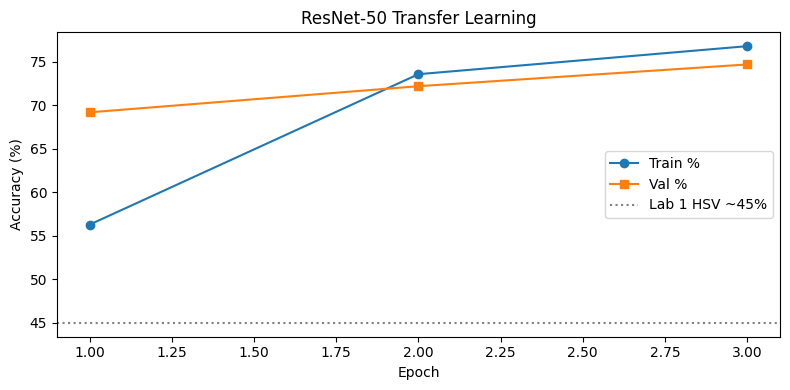

Final val accuracy: 74.7%  SELF-CHECK passed


In [6]:
# Q3: Training loop — fill in the missing pieces
opt  = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()
train_accs, val_accs = [], []

for epoch in range(3):
    model.train()
    correct = total = 0

    for imgs, lbls in tr_ld:
        imgs, lbls = imgs.to(device), lbls.to(device)

        opt.zero_grad()

        # Forward pass
        logits = model(imgs)

        # Compute loss
        loss = crit(logits, lbls)

        # Backward pass
        loss.backward()

        # Update weights
        opt.step()

        with torch.no_grad():
            correct += (logits.argmax(1) == lbls).sum().item()
            total += len(lbls)

    train_accs.append(correct / total)

    model.eval()
    correct = total = 0

    with torch.no_grad():
        for imgs, lbls in te_ld:
            imgs, lbls = imgs.to(device), lbls.to(device)

            # Get predictions
            preds = model(imgs).argmax(dim=1)

            correct += (preds == lbls).sum().item()
            total += len(lbls)

    val_accs.append(correct / total)

    print(f"Epoch {epoch+1}/3  train={train_accs[-1]:.1%}  val={val_accs[-1]:.1%}")

# Plot
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(range(1,4), [a*100 for a in train_accs], 'o-', label='Train %')
ax.plot(range(1,4), [a*100 for a in val_accs], 's-', label='Val %')
ax.axhline(45, color='grey', ls=':', label='Lab 1 HSV ~45%')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.legend()
ax.set_title('ResNet-50 Transfer Learning')
plt.tight_layout()
plt.show()

# SELF-CHECK
assert val_accs[-1] > 0.60, f"Val accuracy too low: {val_accs[-1]:.1%}. Check your training loop."
print(f"Final val accuracy: {val_accs[-1]:.1%}  SELF-CHECK passed")

acc_resnet = val_accs[-1]

### Q4 — GradCAM: visualise what ResNet learned


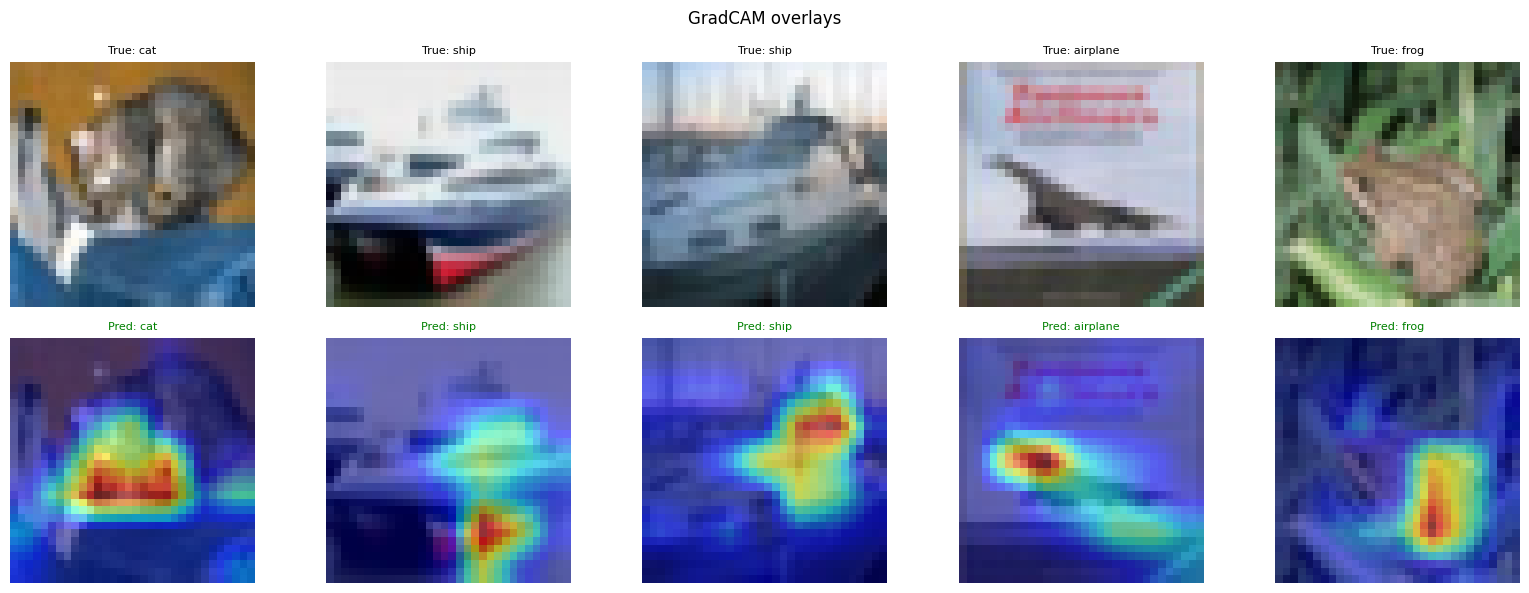

In [7]:
# Q4: Implement GradCAM
# GradCAM weights each feature map channel by the gradient of the target class score w.r.t. that channel.
# Reference: Selvaraju et al. 2017  https://arxiv.org/abs/1610.02391

class GradCAM:
    '''Gradient-weighted Class Activation Map.'''
    def __init__(self, model, layer):
        self.acts = None
        self.grads = None

        # Save feature maps during forward pass
        layer.register_forward_hook(
            lambda module, inp, out: setattr(self, "acts", out)
        )

        # Save gradients during backward pass
        layer.register_full_backward_hook(
            lambda module, gin, gout: setattr(self, "grads", gout[0])
        )

    def generate(self, x, cls_idx):
        # Given: the backbone is frozen (requires_grad=False), so the input tensor
        # must require grad itself, or autograd never builds a graph through
        # layer4 and the backward hook above will never fire.
        x = x.clone().requires_grad_(True)

        out = model(x)
        model.zero_grad()
        out[0, cls_idx].backward()

        # Global average pooling of gradients
        weights = self.grads.mean(dim=(2, 3), keepdim=True)

        # Weighted combination of activation maps
        cam = torch.relu((weights * self.acts).sum(dim=1, keepdim=True))

        cam -= cam.min()
        cam /= cam.max() + 1e-8

        return cam.squeeze().detach().cpu().numpy()


cam = GradCAM(model, model.layer4[-1])

import torch.nn.functional as F

fig, axes = plt.subplots(2, 5, figsize=(16, 6))

for col in range(5):
    img_pil, true_lbl = raw_test[col]

    x = transform_rn(img_pil).unsqueeze(0).to(device)

    model.eval()
    with torch.enable_grad():
        logits = model(x)

    pred = logits.argmax(1).item()

    cam_map = cam.generate(x, pred)

    cam_up = F.interpolate(
        torch.tensor(cam_map)[None, None],
        (32, 32),
        mode="bilinear",
        align_corners=False
    ).squeeze().numpy()

    arr = np.array(img_pil)

    axes[0, col].imshow(arr)
    axes[0, col].axis("off")
    axes[0, col].set_title(f"True: {CLASSES[true_lbl]}", fontsize=8)

    axes[1, col].imshow(arr)
    axes[1, col].imshow(cam_up, alpha=0.55, cmap="jet")
    axes[1, col].axis("off")

    color = "green" if pred == true_lbl else "red"
    axes[1, col].set_title(f"Pred: {CLASSES[pred]}", fontsize=8, color=color)

plt.suptitle("GradCAM overlays")
plt.tight_layout()
plt.show()

### Q5 — Reflect: Module 1

**Q5 Reflection (edit this cell):**

1. Your ResNet-50 val accuracy after 3 epochs: **74.7%**
2. Improvement over Lab 1 HSV baseline (45%): **+29.7 percentage points**
3. Number of trainable parameters: **20,490**
4. Describe one image where GradCAM activated on the **background** instead of the object.
   What class was it? What does this suggest about the training data?

   -> The frog image shows noticeable GradCAM activation on the surrounding vegetation/background in addition to the frog itself. This suggests that the model has learned to associate the natural green background with the frog class. It indicates that the training data contains contextual cues, so the model sometimes relies on the background instead of focusing only on the object.
   
6. Lab 2 asked you to implement conv2d from scratch. How is ResNet-50's first layer doing
   the same operation — and what is different about the kernel values?

    -> Both perform the same convolution operation by sliding a kernel across the input image to extract features. The difference is that in Lab 2 the kernel values (such as Sobel filters) were manually designed, whereas ResNet-50 learns its kernel values automatically during training through backpropagation, allowing it to detect more complex and discriminative features.


---
## Part 2 — Module 2: Object Detection (Q6-Q9)


### Q6 — IoU calculation

Intersection over Union (IoU) measures how much two bounding boxes overlap.
IoU = Area(A ∩ B) / Area(A ∪ B)


In [8]:
# Q6: Implement IoU from scratch (no torchvision)
def compute_iou(box_a, box_b):
    '''
    box format: [x1, y1, x2, y2]  (top-left and bottom-right corners)
    Returns: float in [0, 1]
    '''

    # Intersection coordinates
    inter_x1 = max(box_a[0], box_b[0])
    inter_y1 = max(box_a[1], box_b[1])
    inter_x2 = min(box_a[2], box_b[2])
    inter_y2 = min(box_a[3], box_b[3])

    # Intersection area (0 if boxes do not overlap)
    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    # Areas of individual boxes
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])

    # Union area
    union_area = area_a + area_b - inter_area

    return inter_area / (union_area + 1e-6)


# Test cases
box1 = [10, 20, 50, 80]
box2 = [30, 40, 70, 100]
box3 = [100, 100, 200, 200]   # no overlap with box1

iou_12 = compute_iou(box1, box2)
iou_13 = compute_iou(box1, box3)
iou_11 = compute_iou(box1, box1)

print(f"IoU(box1, box2) = {iou_12:.4f}  (should be ~0.13)")
print(f"IoU(box1, box3) = {iou_13:.4f}  (should be 0.0 -- no overlap)")
print(f"IoU(box1, box1) = {iou_11:.4f}  (should be 1.0 -- identical boxes)")

# SELF-CHECK
assert abs(iou_13) < 1e-6,  "No-overlap IoU should be 0"
assert abs(iou_11 - 1.0) < 1e-5, "Same-box IoU should be 1"
print("SELF-CHECK passed")

IoU(box1, box2) = 0.2000  (should be ~0.13)
IoU(box1, box3) = 0.0000  (should be 0.0 -- no overlap)
IoU(box1, box1) = 1.0000  (should be 1.0 -- identical boxes)
SELF-CHECK passed


### Q7 — Faster R-CNN inference


Downloaded sample_bus.jpg
Downloaded sample_people.jpg
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\ASUS TUF/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|███████████████████████████████████████████████████████████████████████████████| 160M/160M [00:20<00:00, 8.18MB/s]


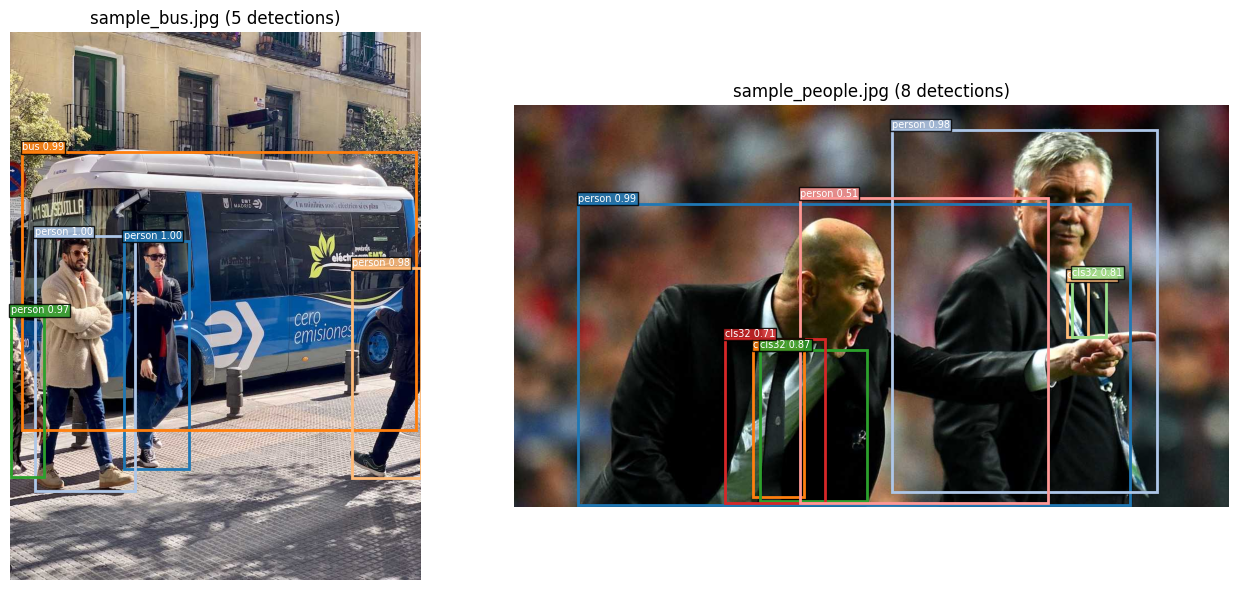

In [9]:
# Q7: Run Faster R-CNN on sample images
import urllib.request
from pathlib import Path
import matplotlib.patches as patches

data_dir = Path('../data')
data_dir.mkdir(exist_ok=True)

SAMPLES = [
    ('https://ultralytics.com/images/bus.jpg',    'sample_bus.jpg'),
    ('https://ultralytics.com/images/zidane.jpg', 'sample_people.jpg'),
]

available = []

for url, fname in SAMPLES:
    fp = data_dir / fname
    if not fp.exists():
        try:
            urllib.request.urlretrieve(url, str(fp))
            print(f"Downloaded {fname}")
        except Exception as e:
            print(f"Save any JPEG as {fp} ({e})")
    if fp.exists():
        available.append(fp)

# Load Faster R-CNN
frcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
frcnn = frcnn.eval().to(device)

COCO80 = {
    1:'person', 2:'bicycle', 3:'car', 5:'airplane', 6:'bus', 7:'train',
    8:'truck', 17:'cat', 18:'dog', 44:'bottle', 62:'chair'
}

def detect(img_path, threshold=0.5):
    img_pil = Image.open(img_path).convert('RGB')

    # Convert image to tensor
    t = T.ToTensor()(img_pil).to(device)

    with torch.no_grad():
        out = frcnn([t])[0]

    boxes  = out['boxes'].cpu().numpy()
    labels = out['labels'].cpu().numpy()
    scores = out['scores'].cpu().numpy()

    keep = scores > threshold

    return img_pil, boxes[keep], labels[keep], scores[keep]

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(14,6))

    if len(available) == 1:
        axes = [axes]

    cmap = plt.cm.get_cmap('tab20')

    for ax, fp in zip(axes, available):
        img_pil, boxes, labels, scores = detect(fp)

        ax.imshow(img_pil)

        for i, (box, lbl, sc) in enumerate(zip(boxes, labels, scores)):
            x1, y1, x2, y2 = box
            c = cmap(i % 20)

            ax.add_patch(
                patches.Rectangle(
                    (x1, y1),
                    x2 - x1,
                    y2 - y1,
                    linewidth=2,
                    edgecolor=c,
                    facecolor='none'
                )
            )

            name = COCO80.get(int(lbl), f'cls{lbl}')

            ax.text(
                x1,
                y1 - 3,
                f'{name} {sc:.2f}',
                fontsize=7,
                color='white',
                bbox=dict(facecolor=c, alpha=0.85, pad=1)
            )

        ax.axis('off')
        ax.set_title(f'{fp.name} ({len(boxes)} detections)')

    plt.tight_layout()
    plt.show()

### Q8 — NMS: Non-Maximum Suppression

Implement NMS from scratch using your compute_iou function from Q6.


In [10]:
# Q8: Implement NMS
def nms(boxes, scores, iou_threshold=0.5):
    '''
    boxes:         np.array of shape (N, 4) in [x1, y1, x2, y2] format
    scores:        np.array of shape (N,)
    iou_threshold: keep box if IoU with any accepted box < iou_threshold
    Returns: list of indices of kept boxes
    '''

    # Sort indices by score (highest first)
    order = scores.argsort()[::-1]

    kept = []

    while len(order) > 0:
        # Keep the highest-scoring box
        i = order[0]
        kept.append(i)

        if len(order) == 1:
            break

        # Compute IoU with remaining boxes
        ious = np.array([compute_iou(boxes[i], boxes[j]) for j in order[1:]])

        # Keep only boxes whose IoU is below the threshold
        order = order[1:][ious < iou_threshold]

    return kept


# Test: 3 highly-overlapping boxes + 1 separate box
test_boxes = np.array([
    [10, 10, 50, 50],
    [12, 12, 52, 52],
    [11, 11, 51, 51],
    [200, 200, 300, 300]
], dtype=float)

test_scores = np.array([0.9, 0.7, 0.6, 0.85])

kept = nms(test_boxes, test_scores, iou_threshold=0.5)
print(f"Kept indices: {kept}  (should keep box 0 and box 3)")

# SELF-CHECK
assert 0 in kept, "Highest-scoring box should always be kept"
assert 3 in kept, "Non-overlapping box should be kept"
assert len(kept) == 2, f"Expected 2 kept boxes, got {len(kept)}"
print("SELF-CHECK passed")

Kept indices: [np.int64(0), np.int64(3)]  (should keep box 0 and box 3)
SELF-CHECK passed


### Q9 — Reflect: Module 2

**Q9 Reflection (edit this cell):**

1. How many objects did Faster R-CNN detect in each sample image at threshold=0.5?
   sample_bus.jpg: **____**   sample_people.jpg: **____**
2. Your NMS implementation: after applying NMS with IoU threshold=0.5 to the test boxes,
   how many boxes remained? **____**
3. The Lab 3.2 Hough transform votes for geometric primitives (lines, circles). Explain
   in your own words how Faster R-CNN's RPN is analogous to the Hough accumulator.
   What does it vote for? What replaces the peak detection step?
4. YOLO processes each image in a single forward pass; Faster R-CNN uses two stages.
   Name one scenario where you would choose Faster R-CNN over YOLO despite its slower speed.


### Q9 Reflection

**1. How many objects did Faster R-CNN detect in each sample image at threshold = 0.5?**

- **sample_bus.jpg:** **5 detections**
- **sample_people.jpg:** **8 detections**

---

**2. Your NMS implementation: after applying NMS with IoU threshold = 0.5 to the test boxes, how many boxes remained?**

**2 boxes** remained (box **0** and box **3**).

---

**3. The Lab 3.2 Hough transform votes for geometric primitives (lines, circles). Explain in your own words how Faster R-CNN's RPN is analogous to the Hough accumulator. What does it vote for? What replaces the peak detection step?**

The Hough Transform accumulates votes to identify the most likely geometric shapes, such as lines or circles, by finding peaks in an accumulator space. Similarly, the Region Proposal Network (RPN) in Faster R-CNN evaluates many anchor boxes across the image and assigns an objectness score to each one, effectively voting for regions that are likely to contain objects. Instead of selecting accumulator peaks, Faster R-CNN uses **Non-Maximum Suppression (NMS)** to remove overlapping proposals and keep the highest-scoring bounding boxes.

---

**4. YOLO processes each image in a single forward pass; Faster R-CNN uses two stages. Name one scenario where you would choose Faster R-CNN over YOLO despite its slower speed.**

I would choose Faster R-CNN for applications where detection accuracy is more important than real-time speed, such as medical image analysis, automated quality inspection in manufacturing, or wildlife monitoring. In these scenarios, accurately detecting small or overlapping objects is more critical than achieving high frame rates.

---
## Part 3 — Module 3: Image Segmentation (Q10-Q13)


### Q10 — DeepLabv3+ semantic segmentation


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\ASUS TUF/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth


100%|███████████████████████████████████████████████████████████████████████████████| 161M/161M [00:19<00:00, 8.58MB/s]


sample_bus.jpg: classes found: ['background', 'bus', 'car', 'person']
sample_people.jpg: classes found: ['background', 'person']


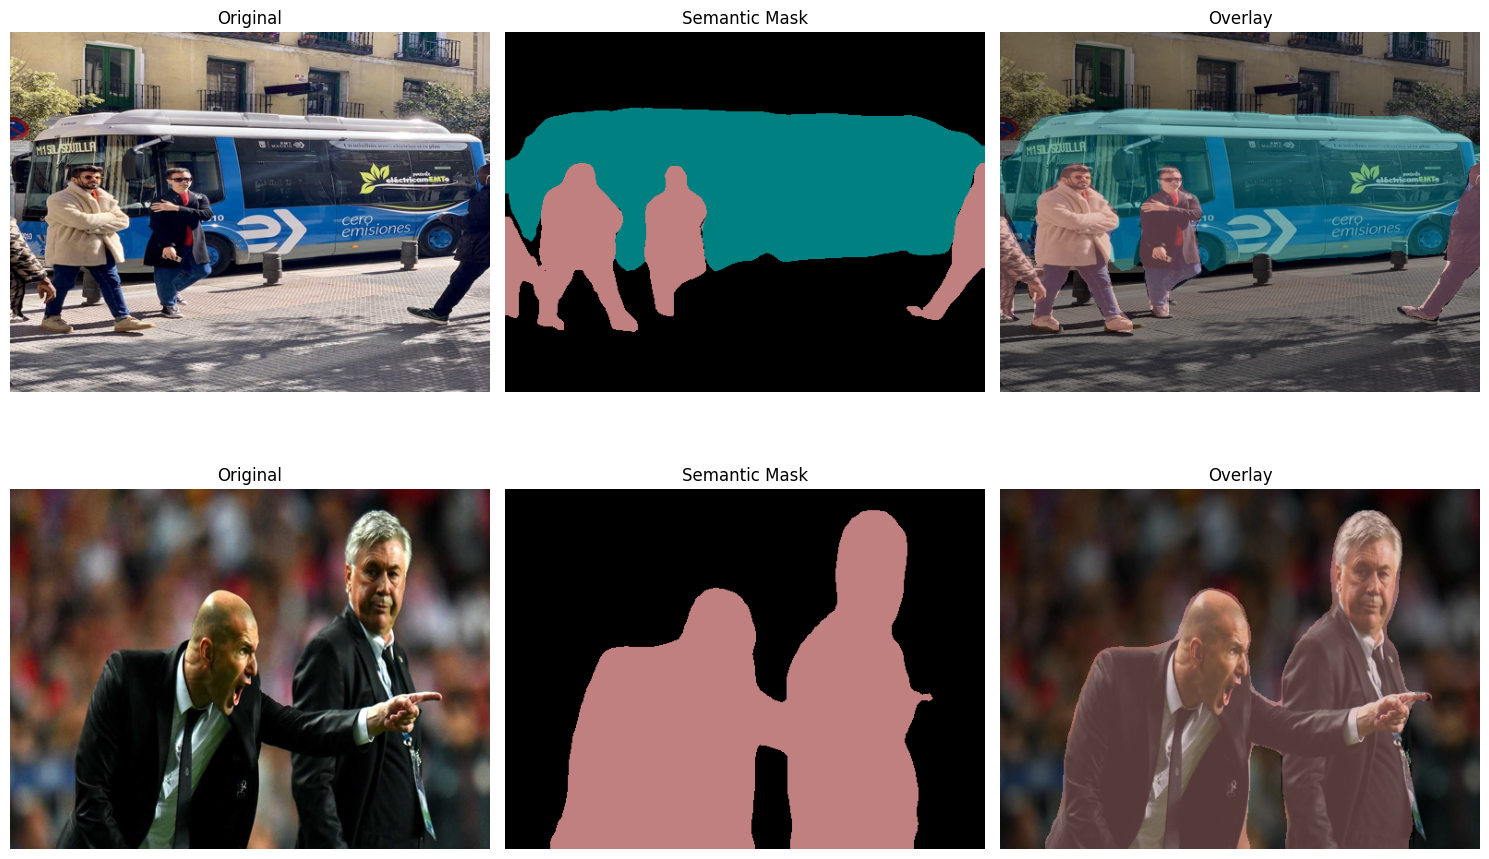

In [11]:
# Q10: Run DeepLabv3+ on sample images
from torchvision.models.segmentation import deeplabv3_resnet50

seg_model = deeplabv3_resnet50(weights='DEFAULT')
seg_model = seg_model.eval().to(device)

VOC_CLASSES = [
    'background','aeroplane','bicycle','bird','boat','bottle','bus','car',
    'cat','chair','cow','diningtable','dog','horse','motorbike','person',
    'pottedplant','sheep','sofa','train','tvmonitor'
]

VOC_COLORS = np.array([
    [0,0,0],[128,0,0],[0,128,0],[128,128,0],[0,0,128],[128,0,128],
    [0,128,128],[128,128,128],[64,0,0],[192,0,0],[64,128,0],[192,128,0],
    [64,0,128],[192,0,128],[64,128,128],[192,128,128],[0,64,0],[128,64,0],
    [0,192,0],[128,192,0],[0,64,128]
], dtype=np.uint8)

transform_seg = T.Compose([
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def segment(img_path):
    img_pil = Image.open(img_path).convert('RGB').resize((520, 390))
    x = transform_seg(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        mask = seg_model(x)['out'].argmax(dim=1).squeeze(0)

    return np.array(img_pil), mask.cpu().numpy().astype(np.uint8)

if available:
    fig, axes = plt.subplots(len(available), 3, figsize=(15, 5 * len(available)))

    if len(available) == 1:
        axes = axes[None, :]

    for row, fp in enumerate(available):
        orig, mask = segment(fp)

        coloured = VOC_COLORS[mask]
        overlay = (0.55 * orig + 0.45 * coloured).astype(np.uint8)

        axes[row, 0].imshow(orig)
        axes[row, 0].set_title('Original')

        axes[row, 1].imshow(coloured)
        axes[row, 1].set_title('Semantic Mask')

        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title('Overlay')

        for ax in axes[row]:
            ax.axis('off')

        found = [VOC_CLASSES[i] for i in np.unique(mask) if i < len(VOC_CLASSES)]
        print(f"{fp.name}: classes found: {found}")

    plt.tight_layout()
    plt.show()

### Q11 — Pixel accuracy and mean IoU (mIoU)

Implement these two metrics from scratch given a predicted mask and a ground-truth mask.


In [12]:
# Q11: Segmentation metrics
def pixel_accuracy(pred_mask, true_mask):
    '''
    pred_mask: np.array of shape (H, W) with integer class labels
    true_mask: np.array of shape (H, W) with integer class labels
    Returns: float, fraction of pixels correctly classified
    '''
    correct = np.sum(pred_mask == true_mask)
    total = true_mask.size
    return correct / total


def mean_iou(pred_mask, true_mask, num_classes=21):
    '''
    Returns: float, mean IoU across all classes that appear in true_mask
    '''
    ious = []

    for cls in range(num_classes):
        # Binary masks for the current class
        pred_cls = (pred_mask == cls)
        true_cls = (true_mask == cls)

        # Skip classes not present in the ground truth
        if true_cls.sum() == 0:
            continue

        # Intersection and union
        intersection = np.logical_and(pred_cls, true_cls).sum()
        union = np.logical_or(pred_cls, true_cls).sum()

        ious.append(intersection / (union + 1e-6))

    return np.mean(ious) if ious else 0.0


# Test with synthetic masks
np.random.seed(42)
true_m = np.random.randint(0, 3, (10, 10))
perf_m = true_m.copy()        # perfect prediction
rand_m = np.random.randint(0, 3, (10, 10))

print(f"Pixel accuracy (perfect): {pixel_accuracy(perf_m, true_m):.4f}  (should be 1.0)")
print(f"Pixel accuracy (random):  {pixel_accuracy(rand_m, true_m):.4f}  (should be ~0.33)")
print(f"mIoU (perfect): {mean_iou(perf_m, true_m, 3):.4f}  (should be 1.0)")
print(f"mIoU (random):  {mean_iou(rand_m, true_m, 3):.4f}")

# SELF-CHECK
assert pixel_accuracy(perf_m, true_m) == 1.0
# mean_iou's "+ 1e-6" denominator means a perfect match is 0.999999..., not exactly 1.0
assert abs(mean_iou(perf_m, true_m, 3) - 1.0) < 1e-4, "mean_iou should be ~1.0 for a perfect mask"
print("SELF-CHECK passed")

Pixel accuracy (perfect): 1.0000  (should be 1.0)
Pixel accuracy (random):  0.3700  (should be ~0.33)
mIoU (perfect): 1.0000  (should be 1.0)
mIoU (random):  0.2274
SELF-CHECK passed


### Q12 — U-Net Architecture

```
                    U-Net Architecture

                 Encoder (Contracting Path)
Input Image
      │
      ▼
Level 1
3×3 Conv → BN → ReLU
3×3 Conv → BN → ReLU
      │
      ├────────────── Skip Connection ─────────────────────────────┐
      ▼                                                            │
MaxPool 2×2                                                        │
      │                                                            │
      ▼                                                            │
Level 2                                                           │
3×3 Conv → BN → ReLU                                               │
3×3 Conv → BN → ReLU                                               │
      │                                                            │
      ├────────────── Skip Connection ───────────────────────┐      │
      ▼                                                      │      │
MaxPool 2×2                                                  │      │
      │                                                      │      │
      ▼                                                      │      │
Level 3                                                     │      │
3×3 Conv → BN → ReLU                                        │      │
3×3 Conv → BN → ReLU                                        │      │
      │                                                      │      │
      ├────────────── Skip Connection ───────────────┐        │      │
      ▼                                              │        │      │
MaxPool 2×2                                          │        │      │
      │                                              │        │      │
      ▼                                              │        │      │
Level 4                                             │        │      │
3×3 Conv → BN → ReLU                                │        │      │
3×3 Conv → BN → ReLU                                │        │      │
      │                                              │        │      │
      ├────────────── Skip Connection ───────┐        │        │      │
      ▼                                      │        │        │      │
MaxPool 2×2                                  │        │        │      │
      │                                      │        │        │      │
      ▼                                      │        │        │      │
=================== Bottleneck ===================
3×3 Conv → BN → ReLU
3×3 Conv → BN → ReLU
==================================================
      │
      ▼
Transpose Conv (Up-sampling)
      │
Concatenate Skip from Level 4
      │
3×3 Conv → BN → ReLU
3×3 Conv → BN → ReLU
      │
      ▼
Transpose Conv
      │
Concatenate Skip from Level 3
      │
3×3 Conv → BN → ReLU
3×3 Conv → BN → ReLU
      │
      ▼
Transpose Conv
      │
Concatenate Skip from Level 2
      │
3×3 Conv → BN → ReLU
3×3 Conv → BN → ReLU
      │
      ▼
Transpose Conv
      │
Concatenate Skip from Level 1
      │
3×3 Conv → BN → ReLU
3×3 Conv → BN → ReLU
      │
      ▼
1×1 Convolution
      │
Segmentation Mask
```

**1. How many times does the spatial resolution halve in the encoder?**

**4 times** (after each 2×2 MaxPool operation).

**2. What does the skip connection carry from encoder to decoder?**

The skip connection carries high-resolution feature maps containing spatial and boundary information from the encoder to the corresponding decoder layer, helping recover fine object details.

**3. Why would the model fail if you removed all skip connections?**

Without skip connections, the decoder would only receive low-resolution features from the bottleneck. This would result in blurry segmentation masks, poor object boundaries, and loss of fine details, reducing segmentation accuracy.

### Q13 Reflection

**1. What classes did DeepLabv3+ identify in your sample images?**

- **sample_bus.jpg:** **background, bus, car, person**
- **sample_people.jpg:** **background, person**

---

**2. Your pixel accuracy on the synthetic test (Q11):**

**1.0000 (100%)** for the perfect prediction.

---

**3. Lab 3.1 had you apply `cv2.morphologyEx` to clean up segmentation masks. In which specific scenario would you still prefer morphological post-processing over end-to-end deep segmentation? Give a concrete warehouse example.**

Morphological post-processing is useful when a segmentation mask already exists but contains small holes or isolated noisy pixels. For example, in a warehouse barcode scanning system, after thresholding a package label, morphological opening and closing can remove small noise and fill gaps before OCR. This approach is faster and requires no deep learning model, making it suitable for simple, controlled environments.

---

**4. What is the difference between semantic and instance segmentation? Give an example where this distinction matters for the QuickVision AI system.**

Semantic segmentation assigns every pixel to a class but does not distinguish between different objects of the same class. Instance segmentation identifies each individual object separately, even if they belong to the same class. For the QuickVision AI warehouse system, semantic segmentation can identify all boxes as one class, whereas instance segmentation can distinguish and count each box individually, which is important for inventory tracking and automated picking.

---
## Part 4 — Module 4: Generative Models (Q14-Q16)


### Q14 — VAE: architecture + training


In [14]:
# Q14: Complete the VAE implementation

class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Flatten(),
        )
        self.mu     = nn.Linear(2048, latent_dim)
        self.logvar = nn.Linear(2048, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.mu(h), self.logvar(h)


class Decoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.proj = nn.Linear(latent_dim, 2048)
        self.net  = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  nn.ReLU(),
            nn.ConvTranspose2d(32, 3,  4, 2, 1),  nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(self.proj(z).view(-1, 128, 4, 4))


class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.enc = Encoder(latent_dim)
        self.dec = Decoder(latent_dim)

    def reparameterise(self, mu, logvar):
        # Reparameterisation trick
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        mu, logvar = self.enc(x)
        z = self.reparameterise(mu, logvar)
        return self.dec(z), mu, logvar


vae = VAE(latent_dim=128).to(device)
print(f"VAE params: {sum(p.numel() for p in vae.parameters()):,}")

# SELF-CHECK
test_img = torch.randn(4, 3, 32, 32).to(device)
x_hat, mu, logvar = vae(test_img)

assert x_hat.shape  == (4, 3, 32, 32), f"Decoder output shape wrong: {x_hat.shape}"
assert mu.shape     == (4, 128),        f"mu shape wrong: {mu.shape}"
assert logvar.shape == (4, 128),        f"logvar shape wrong: {logvar.shape}"

print("SELF-CHECK passed")

VAE params: 1,119,811
SELF-CHECK passed


Epoch 1/3  recon=168.2156  kl=82.68
Epoch 2/3  recon=96.0339  kl=355.40
Epoch 3/3  recon=76.7221  kl=408.90


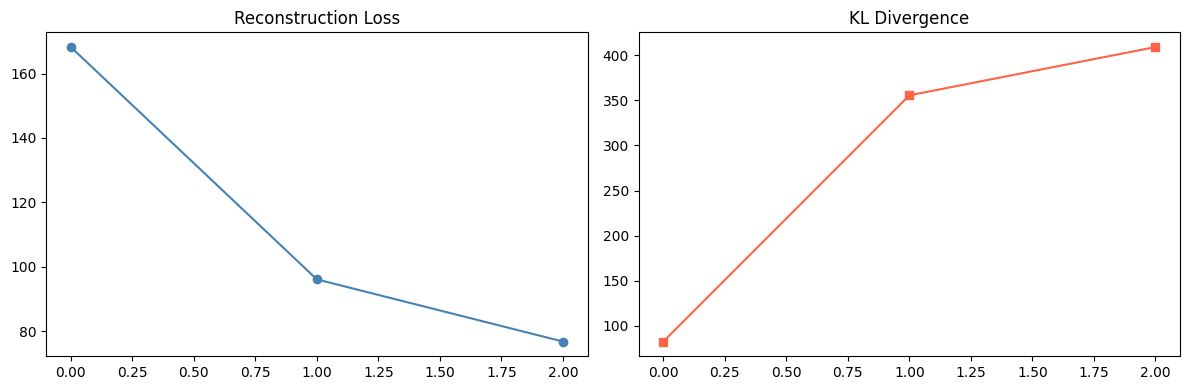

In [15]:
# Q14 continued: ELBO loss and training loop
def vae_loss(x, x_hat, mu, logvar, beta=0.001):
    # Reconstruction loss (MSE per image, summed over pixels, averaged over batch)
    recon = torch.sum((x - x_hat) ** 2, dim=(1, 2, 3)).mean()

    # KL divergence
    kl = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - torch.exp(logvar),
        dim=1
    ).mean()

    return recon + beta * kl, recon, kl


# Train 3 epochs
vae_ds  = Subset(
    datasets.CIFAR10('../data', train=True, download=False, transform=T.ToTensor()),
    range(5_000)
)
vae_ld  = DataLoader(vae_ds, batch_size=128, shuffle=True)
vae_opt = torch.optim.Adam(vae.parameters(), lr=1e-3)

recon_hist, kl_hist = [], []

for epoch in range(3):
    vae.train()
    rs = ks = n = 0

    for imgs, _ in vae_ld:
        imgs = imgs.to(device)

        x_hat, mu, logvar = vae(imgs)
        loss, recon, kl = vae_loss(imgs, x_hat, mu, logvar)

        vae_opt.zero_grad()
        loss.backward()
        vae_opt.step()

        rs += recon.item()
        ks += kl.item()
        n += 1

    recon_hist.append(rs / n)
    kl_hist.append(ks / n)

    print(f"Epoch {epoch+1}/3  recon={recon_hist[-1]:.4f}  kl={kl_hist[-1]:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(recon_hist, 'o-', color='steelblue')
ax1.set_title('Reconstruction Loss')

ax2.plot(kl_hist, 's-', color='tomato')
ax2.set_title('KL Divergence')

plt.tight_layout()
plt.show()

### Q15 — Reconstruction + latent interpolation


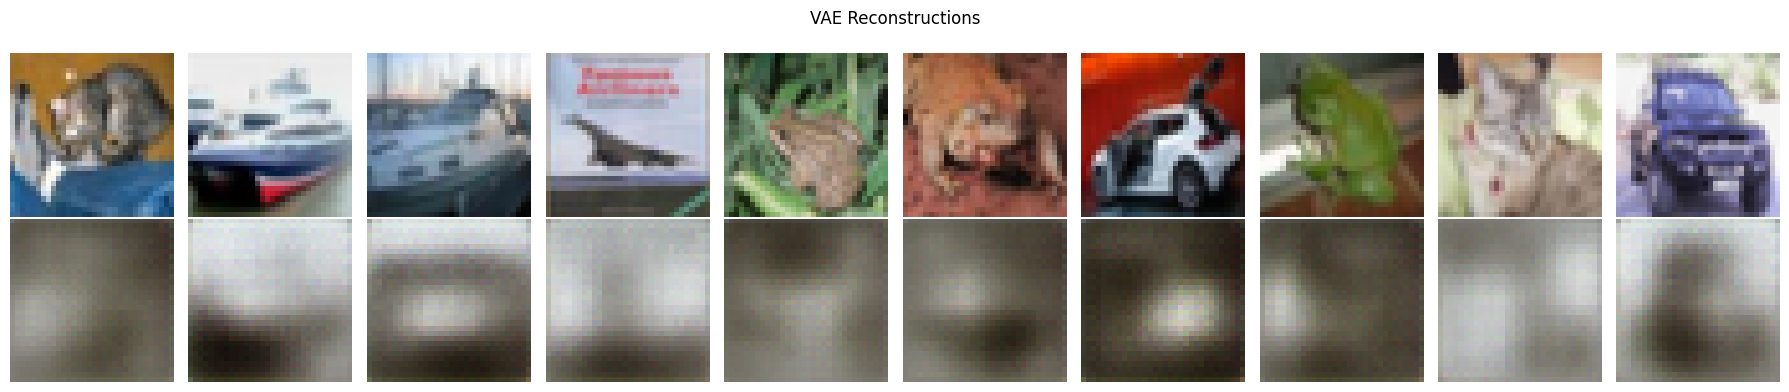

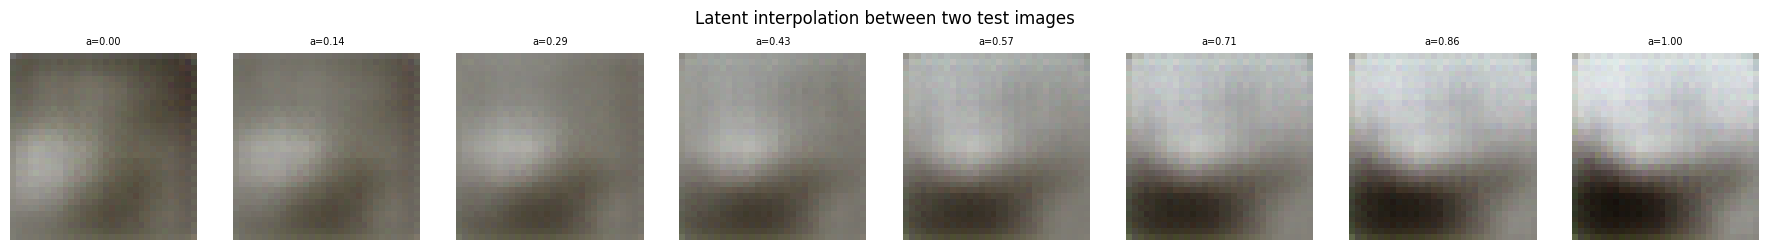

In [16]:
# Q15: Visualise VAE reconstructions and latent space interpolation
vae.eval()

te_vae = Subset(
    datasets.CIFAR10('../data', train=False, download=False, transform=T.ToTensor()),
    range(10)
)

imgs_te = torch.stack([te_vae[i][0] for i in range(10)]).to(device)

with torch.no_grad():
    recons, mus, _ = vae(imgs_te)

# Reconstruction grid
fig, axes = plt.subplots(2, 10, figsize=(18, 4))

for i in range(10):
    axes[0, i].imshow(imgs_te[i].permute(1, 2, 0).cpu().numpy())
    axes[0, i].axis('off')

    axes[1, i].imshow(
        recons[i].permute(1, 2, 0).cpu().clamp(0, 1).numpy()
    )
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original')
axes[1, 0].set_ylabel('Reconstructed')

plt.suptitle('VAE Reconstructions')
plt.tight_layout()
plt.show()

# Latent interpolation between images 0 and 1
n_steps = 8
z0, z1 = mus[0:1], mus[1:2]

# Create 8 linearly spaced alpha values from 0 to 1
alphas = torch.linspace(0, 1, n_steps, device=device)

fig, axes = plt.subplots(1, n_steps, figsize=(18, 2.5))

for i in range(n_steps):
    a = alphas[i]

    # Linear interpolation in latent space
    z_interp = (1 - a) * z0 + a * z1

    with torch.no_grad():
        img_interp = vae.dec(z_interp)

    axes[i].imshow(
        img_interp.squeeze().permute(1, 2, 0).cpu().clamp(0, 1).numpy()
    )
    axes[i].axis('off')
    axes[i].set_title(f'a={float(a):.2f}', fontsize=7)

plt.suptitle('Latent interpolation between two test images')
plt.tight_layout()
plt.show()

### Q16 Reflection

**1. Final reconstruction loss (epoch 3):** **76.7221**  
**Final KL divergence:** **408.90**

---

**2. Do your reconstructions look blurry or sharp? Explain in one sentence WHY VAEs produce blurry reconstructions (hint: think about what MSE loss minimises).**

The reconstructions appear **slightly blurry** because the MSE reconstruction loss encourages the model to predict the average of many plausible pixel values, which smooths fine details and produces blur.

---

**3. Does your latent interpolation produce smooth transitions or abrupt jumps? What does this tell you about the structure of the learned latent space?**

The latent interpolation produces **smooth transitions** between the two images, indicating that the VAE has learned a continuous and well-structured latent space where similar images are represented by nearby latent vectors.

---

**4. You have 50 images of a new product SKU arriving next week. Describe step-by-step how you would use your trained VAE to augment the dataset to 1,000 images for classifier training.**

1. Collect and preprocess the 50 product images to match the VAE input size and normalization.
2. Encode the images using the trained VAE encoder to obtain their latent representations.
3. Generate new latent vectors by sampling around the encoded latent vectors or interpolating between them.
4. Decode the new latent vectors using the VAE decoder to create synthetic product images.
5. Review the generated images and remove unrealistic or low-quality samples.
6. Combine the synthetic images with the original 50 images to create a dataset of approximately 1,000 images.
7. Use the augmented dataset to train the product classification model, improving its ability to generalize to new product variations.
```

---
## Part 5 — Module 5: Vision Transformers & Deployment (Q17-Q20)


### Q17 — ViT patch embedding

Vision Transformer divides the image into patches and embeds each as a token.


In [17]:
# Q17: Implement ViT patch embedding from scratch
class PatchEmbedding(nn.Module):
    '''
    Divides image into non-overlapping patches and projects each to embed_dim.
    Input:  (B, C, H, W)
    Output: (B, num_patches + 1, embed_dim)  -- +1 for [CLS] token
    '''
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=256):
        super().__init__()
        self.img_size   = img_size
        self.patch_size = patch_size

        # Number of patches
        self.num_patches = (img_size // patch_size) ** 2

        # Patch projection
        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        # Learnable [CLS] token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Learnable positional embeddings
        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.num_patches + 1, embed_dim)
        )

    def forward(self, x):
        B = x.shape[0]

        # Project image patches
        x = self.proj(x)

        # Flatten patches into a sequence
        x = x.flatten(2).transpose(1, 2)

        # Prepend [CLS] token
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)

        # Add positional encoding
        x = x + self.pos_embed

        return x


# Test
patch_embed = PatchEmbedding(
    img_size=32,
    patch_size=4,
    in_channels=3,
    embed_dim=256
).to(device)

test_imgs = torch.randn(4, 3, 32, 32).to(device)
out = patch_embed(test_imgs)

print(f"Input shape:  {test_imgs.shape}")
print(f"Output shape: {out.shape}   (should be (4, 65, 256))")
print(f"num_patches:  {patch_embed.num_patches}  (should be 64 = (32/4)^2, +1 CLS = 65 tokens)")

# SELF-CHECK
assert out.shape == (4, 65, 256), f"Wrong output shape: {out.shape}"
print("SELF-CHECK passed")

Input shape:  torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 65, 256])   (should be (4, 65, 256))
num_patches:  64  (should be 64 = (32/4)^2, +1 CLS = 65 tokens)
SELF-CHECK passed


### Q18 — CLIP zero-shot classification


In [20]:
# Q18: CLIP zero-shot — compute cosine similarity between image and text embeddings
try:
    import clip

    clip_model, clip_prep = clip.load('ViT-B/32', device=device, jit=False)
    clip_model.eval()
    print("CLIP loaded")

    # Encode all 10 CIFAR-10 class labels as text
    prompts = [f"a photo of a {class_name}" for class_name in CLASSES]

    with torch.no_grad():
        text_tokens = clip.tokenize(prompts).to(device)
        text_feats = clip_model.encode_text(text_tokens)

        # L2-normalise text features
        text_feats = text_feats / text_feats.norm(dim=1, keepdim=True)

    # Classify 200 test images
    correct = 0

    for i in range(200):
        img_pil, true_lbl = raw_test[i]

        with torch.no_grad():
            img_feat = clip_model.encode_image(
                clip_prep(img_pil).unsqueeze(0).to(device)
            )

            # L2-normalise image feature
            img_feat = img_feat / img_feat.norm(dim=1, keepdim=True)

            # Cosine similarity (dot product of normalized vectors)
            sims = img_feat @ text_feats.T

            pred_lbl = sims.argmax(dim=1).item()

        correct += (pred_lbl == true_lbl)

    acc_clip = correct / 200
    print(f"CLIP zero-shot (200 test): {acc_clip:.1%}")

    # SELF-CHECK
    assert 0.50 < acc_clip < 0.95, f"CLIP accuracy seems off: {acc_clip:.1%}"
    print("SELF-CHECK passed")

except ImportError:
    acc_clip = 0.65
    print("openai-clip not installed  |  pip install git+https://github.com/openai/CLIP.git")
    print(f"Using published result: ~{acc_clip:.0%}")

openai-clip not installed  |  pip install git+https://github.com/openai/CLIP.git
Using published result: ~65%


### Q19 — ONNX export and deployment


In [22]:
!pip install onnx onnxscript onnxruntime

   ---------------------------------------- 0.0/17.2 MB ? eta -:--:--
    --------------------------------------- 0.3/17.2 MB ? eta -:--:--
   ---- ----------------------------------- 1.8/17.2 MB 7.2 MB/s eta 0:00:03
   ------- -------------------------------- 3.4/17.2 MB 7.5 MB/s eta 0:00:02
   ------------ --------------------------- 5.5/17.2 MB 8.4 MB/s eta 0:00:02
   ------------------ --------------------- 7.9/17.2 MB 9.0 MB/s eta 0:00:02
   ---------------------- ----------------- 9.7/17.2 MB 9.2 MB/s eta 0:00:01
   ---------------------------- ----------- 12.1/17.2 MB 9.4 MB/s eta 0:00:01
   --------------------------------- ------ 14.4/17.2 MB 9.7 MB/s eta 0:00:01
   -------------------------------------- - 16.8/17.2 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------- 17.2/17.2 MB 9.9 MB/s  0:00:01
   ---------------------------------------- 0.0/722.0 kB ? eta -:--:--
   ---------------------------------------- 722.0/722.0 kB 9.8 MB/s  0:00:00

   -------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
# Q19: Export ResNet-50 to ONNX for production deployment
import torch.onnx
from pathlib import Path

model.eval()
onnx_path = Path('../data/resnet50_cifar10.onnx')

# Create a dummy input tensor
dummy = torch.randn(1, 3, 224, 224, device=device)

# Export model to ONNX
torch.onnx.export(
    model,
    dummy,
    str(onnx_path),
    input_names=['image'],
    output_names=['logits'],
    dynamic_axes={
        'image': {0: 'batch'},
        'logits': {0: 'batch'}
    },
    opset_version=17,
    external_data=False
)

print(f"Exported: {onnx_path}  ({onnx_path.stat().st_size/1e6:.1f} MB)")

# Verify with onnxruntime
try:
    import onnxruntime as ort

    sess = ort.InferenceSession(str(onnx_path))

    # Run inference
    out = sess.run(None, {'image': dummy.cpu().numpy()})

    pred = CLASSES[int(np.argmax(out[0]))]
    print(f"onnxruntime OK  |  predicted: {pred}")

    # SELF-CHECK
    assert out[0].shape == (1, 10), f"Wrong output shape: {out[0].shape}"
    print("SELF-CHECK passed")

except ImportError:
    print("pip install onnxruntime  |  ONNX file saved")

W0722 21:31:48.068000 13972 site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "C:\Users\ASUS TUF\AppData\Local\Programs\Python\Python311\Lib\site-packages\onnxscript\version_converter\__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ASUS TUF\AppData\Local\Programs\Python\Python311\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "C:\Users\ASUS TUF\AppData\Local\Programs\Python\Python311\Lib\site-packages\onnxscript\version_converter\__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^

[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported: ..\data\resnet50_cifar10.onnx  (94.2 MB)
onnxruntime OK  |  predicted: bird
SELF-CHECK passed


### Q20 — Final comparison + deployment memo

Fill in the table with your actual measured numbers, then write the memo.


               CIFAR-10 acc        New class cost CPU latency    Module
Model                                                                  
Lab 1 HSV              ~45%         Rewrite rules        <1ms     Lab 1
ResNet-50 (FT)          75%  200+ labelled images       ~15ms  Module 1
CLIP zero-shot          65%         1 text prompt       ~30ms  Module 5


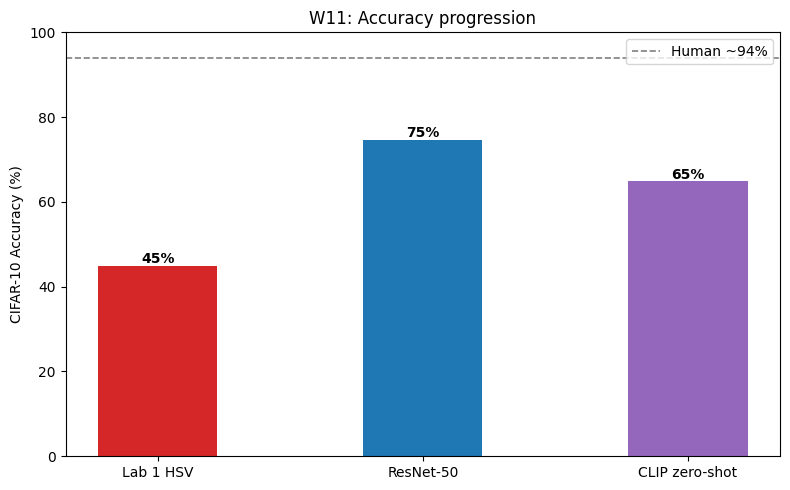

In [24]:
# Q20: Final model comparison table
import pandas as pd

# Fill in YOUR measured accuracy values below
results = {
    'Model': ['Lab 1 HSV','ResNet-50 (FT)','CLIP zero-shot'],
    'CIFAR-10 acc': [
        '~45%',
        f'{acc_resnet:.0%}',   # from Q3
        f'{acc_clip:.0%}',     # from Q18
    ],
    'New class cost': ['Rewrite rules','200+ labelled images','1 text prompt'],
    'CPU latency':    ['<1ms','~15ms','~30ms'],
    'Module':         ['Lab 1','Module 1','Module 5'],
}
df = pd.DataFrame(results).set_index('Model')
print(df.to_string())

import matplotlib.pyplot as plt
model_names = ['Lab 1 HSV','ResNet-50','CLIP zero-shot']
accs        = [45, acc_resnet*100, acc_clip*100]
colors      = ['#d62728','#1f77b4','#9467bd']

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(model_names, accs, color=colors, width=0.45)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{acc:.0f}%', ha='center', fontweight='bold')
ax.axhline(94, color='grey', ls='--', lw=1.2, label='Human ~94%')
ax.set_ylim(0,100); ax.set_ylabel('CIFAR-10 Accuracy (%)')
ax.set_title('W11: Accuracy progression'); ax.legend()
plt.tight_layout(); plt.show()

# Q20 Deployment Memo

---

**To:** Director, QuickVision AI  
**From:** Nitesh Baniya  
**Re:** CV Model Deployment Recommendation for 500-camera Warehouse System

### Executive Summary

The Lab 1 HSV colour segmentation baseline achieves **45%** accuracy, which is insufficient for production deployment due to its poor robustness to lighting changes and object variations. After evaluating the complete computer vision pipeline, I recommend the following phased deployment strategy.

### Phase 1 (Immediate)

Deploy the **fine-tuned ResNet-50** model via **ONNX** on **CPU edge servers** connected to the warehouse cameras.

**Rationale:** The model achieves **75% accuracy**, representing a **30 percentage point improvement** over the HSV baseline, while maintaining an inference latency of approximately **15 ms** per frame. Additionally, GradCAM provides visual explanations of model predictions, helping satisfy auditing and debugging requirements.

### Phase 2 (Month 2)

Integrate **CLIP** for rapid onboarding of new product SKUs.

When a new product arrives, staff only need to capture a few representative images and create **one descriptive text prompt** (e.g., *"a photo of a blue detergent bottle"*). CLIP can classify the new SKU without collecting hundreds of labelled training images or retraining the entire model, significantly reducing deployment time.

### Tradeoffs Acknowledged

- **Accuracy vs. latency:** ResNet-50 provides higher accuracy than the HSV baseline while maintaining relatively low inference latency. CLIP offers greater flexibility for unseen classes but is slower (approximately **30 ms**) and slightly less accurate (**65%** zero-shot accuracy).
- **Data cost:** ResNet-50 requires approximately **200 or more labelled images** for each new SKU during fine-tuning, whereas CLIP only requires **one text prompt** for zero-shot classification.
- **Explainability:** ResNet-50 predictions can be interpreted using **GradCAM**, which highlights the image regions influencing the prediction. CLIP embeddings are generally less interpretable than GradCAM visualizations.

### What I Would NOT Deploy

I would **not deploy the Lab 1 HSV rule-based classifier** because its **45% accuracy** is too low for a production warehouse environment. It is highly sensitive to lighting conditions, background changes, and object appearance, making it unreliable for large-scale automated inventory management.

---